# Avance del proyecto

## Introducción
En esta fase inicial, comenzarás tu inmersión en el análisis predictivo del mercado inmobiliario. Se te proporcionará una base de datos, que contiende datos cruciales sobre el mercado inmobiliario, que incluye, pero no se limita a precios, ubicaciones y características físicas de las propiedades. Llevarás a cabo un análisis exploratorio de datos (EDA) profundo para familiarizarte con estos, prepararlos para el análisis y descubrir patrones iniciales, tendencias y posibles anomalías. Este paso es esencial para cualquier proyecto de ciencia de datos, ya que establece una base sólida para el modelado predictivo posterior.

---

## __Parte 1__: Base de datos
1. Carga la base de datos a Python e importa las librerías que utilizarás a lo largo de todo el análisis.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar base de datos
df = pd.read_csv('Datos/Base_de_datos_Proyecto.csv', sep=",", header=0, index_col=0, encoding="utf-8", engine="python")

# Ver primeras filas
print(df.head())

# Información general
print(df.info())


          log_price property_type        room_type  \
id                                                   
6901257    5.010635     Apartment  Entire home/apt   
6304928    5.129899     Apartment  Entire home/apt   
7919400    4.976734     Apartment  Entire home/apt   
13418779   6.620073         House  Entire home/apt   
3808709    4.744932     Apartment  Entire home/apt   

                                                  amenities  accommodates  \
id                                                                          
6901257   {"Wireless Internet","Air conditioning",Kitche...             3   
6304928   {"Wireless Internet","Air conditioning",Kitche...             7   
7919400   {TV,"Cable TV","Wireless Internet","Air condit...             5   
13418779  {TV,"Cable TV",Internet,"Wireless Internet",Ki...             4   
3808709   {TV,Internet,"Wireless Internet","Air conditio...             2   

          bathrooms  bed_type cancellation_policy  cleaning_fee city  ...  \
id  

## __Parte 2: Análisis Exploratorio de Datos (EDA)__
1. Análisis descriptivo: calcula estadísticas para cada variable (media, mediana, desviación estándar, etc.). Identifica las variables que podrían influir más en el precio de una vivienda.

In [18]:
# Estadísticas básicas
print("========== ESTADÍSTICAS BÁSICAS ==========\n")
print(df.describe())

# Estadísticas incluyendo variables categóricas
print("\n========== ESTADÍSTICAS CON VARIABLES ==========\n")
print(df.describe(include='all'))


========== ESTADÍSTICAS BÁSICAS ==========

          log_price  accommodates     bathrooms      latitude     longitude  \
count  74111.000000  74111.000000  73911.000000  74111.000000  74111.000000   
mean       4.782069      3.155146      1.235263     38.445958    -92.397525   
std        0.717394      2.153589      0.582044      3.080167     21.705322   
min        0.000000      1.000000      0.000000     33.338905   -122.511500   
25%        4.317488      2.000000      1.000000     34.127908   -118.342374   
50%        4.709530      2.000000      1.000000     40.662138    -76.996965   
75%        5.220356      4.000000      1.000000     40.746096    -73.954660   
max        7.600402     16.000000      8.000000     42.390437    -70.985047   

       number_of_reviews  review_scores_rating      bedrooms          beds  
count       74111.000000          57389.000000  74020.000000  73980.000000  
mean           20.900568             94.067365      1.265793      1.710868  
std          

2. Visualización de datos: Genera visualizaciones que ayuden a entender la distribución de las variables más importantes, la relación entre el precio de la vivienda y otras variables para identificar patrones o tendencias. Utiliza Matplotlib, Seaborn o cualquier otra biblioteca de visualización en Python. Ejemplos de gráficos a considerar incluyen histogramas, box plots, scatter plots y mapas de calor para correlaciones.

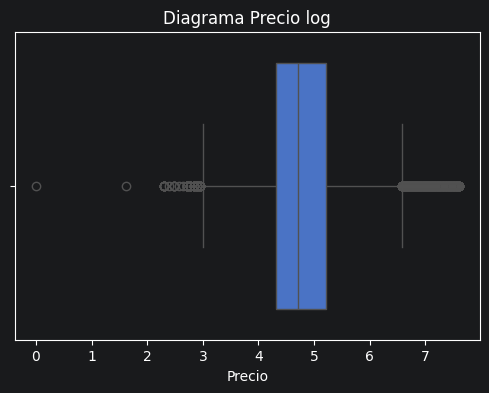

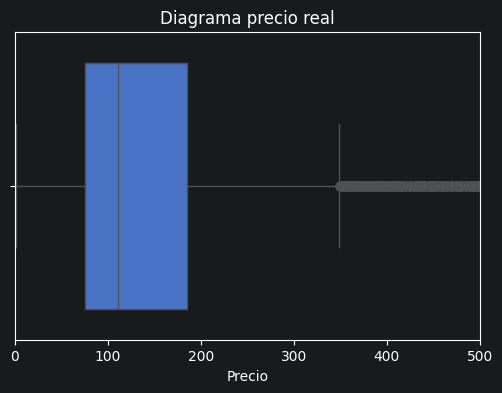

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["log_price"])

plt.title("Diagrama Precio log")
plt.xlabel("Precio")
plt.savefig("./Visualizaciones/Diagrama_precio_log.png")
plt.show()

precio_real = np.exp(df["log_price"])

plt.figure(figsize=(6,4))
sns.boxplot(x=precio_real)

plt.title("Diagrama precio real")
plt.xlabel("Precio")

plt.xlim(0, 500)

plt.savefig("./Visualizaciones/Diagrama_precio_real.png")
plt.show()

## Diagrama de cajas (precio)

Se utilizó un gráfico de cajas (boxplot) para analizar la distribución de los precios de los alojamientos tipo Airbnb en Estados Unidos, sin considerar variables adicionales como amenidades, tipo de cama o número de habitaciones.
Al inicio se utilizó la variable __"log_price"__, la cual representa el logaritmo del precio, pero ya que esta variable no representa directamente a un costo, se realizó una conversión  para obtener el precio real y facilitar su interpretación.

#### Interpretación:
Como podemos observar en las gráficas, los precios de los airbnb sin contemplar cantidad de amenidades, cuartos, tipos de cama ni temporada son de $75.00 - $180.00 USD.

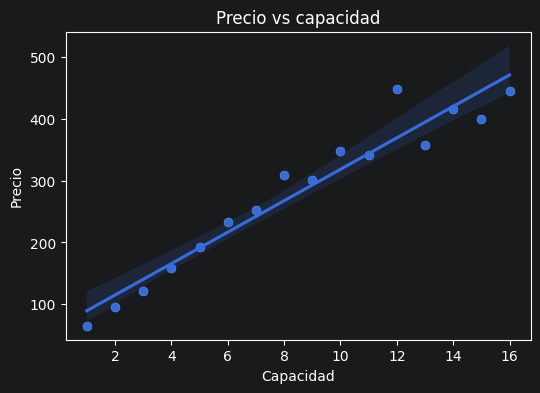

In [14]:
promedio = df.groupby("accommodates")["log_price"].mean()
costo_promedio = np.exp(promedio.values)

plt.figure(figsize=(6,4))
sns.scatterplot(x=promedio.index, y=costo_promedio)
sns.regplot(x=promedio.index, y=costo_promedio)
plt.title("Precio vs capacidad")

plt.xlabel("Capacidad")
plt.ylabel("Precio")

plt.savefig("./Visualizaciones/PrecioCapacidad.png")
plt.show()


## Precio vs Capacidad
Anteriormente, se pudo observar por que precios rondan los Airbnb en Estados Unidos, en esta gráfica se profundiza en los factores que influyen en dichos precios, específicamente la relación entre la capacidad del alojamiento y su costo.

PPara este análisis, se agruparon los datos por la variable __"accommodates"__ y se calculó el promedio de __"log_price"__ para cada grupo, una vez agrupados a los valores promedio de "log_price" se hizo la conversión a un precio real.

#### __Interpretación:__
A partir de la gráfica, se observa una tendencia positiva clara: a medida que aumenta la capacidad del alojamiento, también incrementa el precio promedio. Esto indica que la capacidad es un factor importante en la determinación del precio.


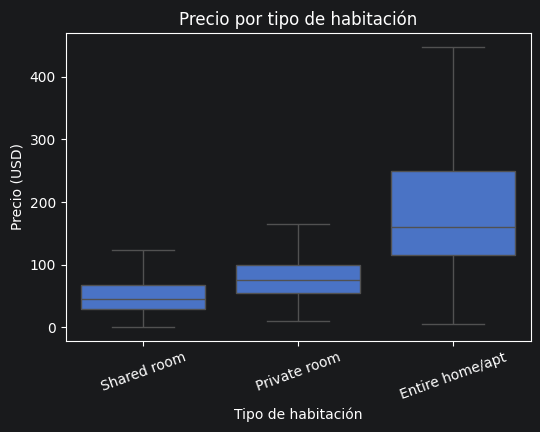

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["room_type"], y=precio_real, order=["Shared room", "Private room", "Entire home/apt"], showfliers=False)

plt.title("Precio por tipo de habitación")
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio (USD)")

plt.xticks(rotation=20)

plt.savefig("./Visualizaciones/PrecioTipoHabitacion.png", dpi=300, bbox_inches="tight")
plt.show()

## Precio por tipo de  habitación
Al analizar el dataset, se identifican tres tipos principales de alojamientos en Airbnb: Shared room, Private room y Entire home/apt. Con el fin de profundizar en el análisis, se evaluó cómo varían los precios entre estos tipos de habitación utilizando un diagrama de cajas.

#### __Interpretación:__
- Shared room: Se puede observar que el precio ronda desde el dólar hasta los 120.00 USD, pero la mayoría se centra de los 20.00 USD a los 70.00 USD.
- Private room: Se puede observa que el precio ronda desde los 10.00 USD hasta los 170.00 USD, pero la mayoría se centra de los 50.00 USD a los 100.00 USD
- Entire home/apt: Por último el tipo de habitación que es más caro ronda desde los 5.00 USD a los 470.00 USD y la mayoría se centra en el rango de los 120.00 USD a los 250.00 USD

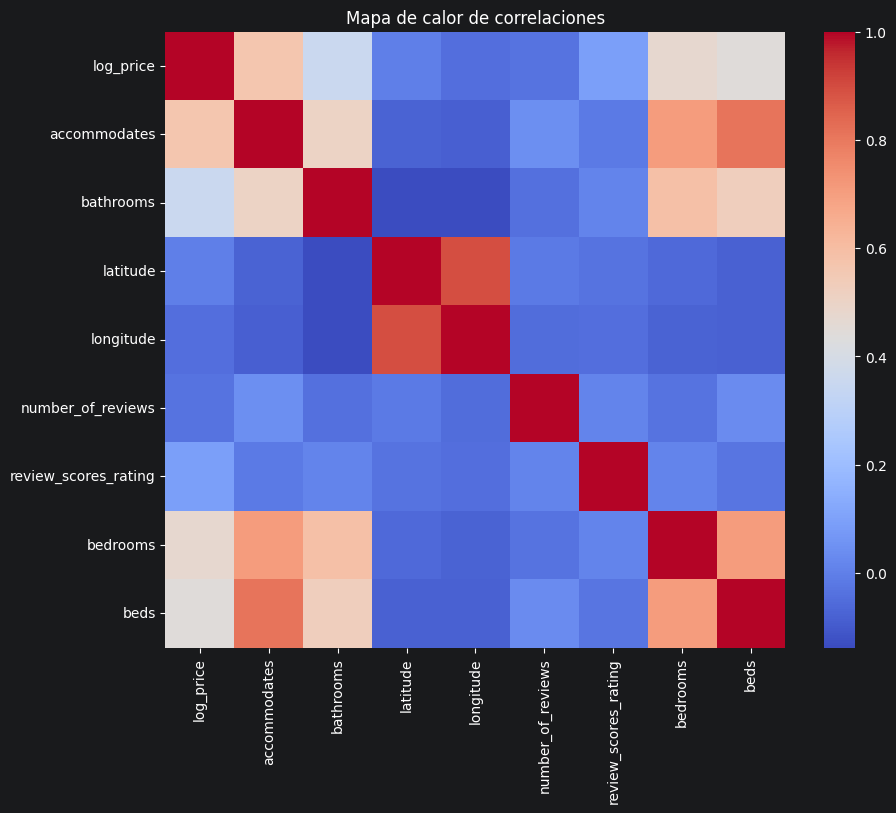

In [17]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Mapa de calor de correlaciones")
plt.savefig("./Visualizaciones/MapaCorrelaciones.png")
plt.show()

## Mapa de calor de Correlaciónes
Con el objetivo de identificar qué variables influyen en el precio de los Airbnb, se utilizó un mapa de calor de correlaciones. Este mapa permite visualizar la relación entre las distintas variables del dataset, facilitando la identificación de aquellas que tienen mayor impacto en el precio.

#### __Interpretación:__
En primer lugar, se descarta la diagonal principal del mapa de calor, ya que representa la correlación de cada variable consigo misma, la cual siempre es igual a 1 y no aporta información relevante para el análisis.

Al analizar la variable log_price, se observa que las variables que muestran mayor correlación positiva son aquellas relacionadas con el tamaño y la capacidad del Airbnb, como accommodates, bedrooms, beds y bathrooms. Esto indica que, a mayor capacidad o tamaño del inmueble, el precio es mayor.

Y variables como latitude y longitude, que representan la ubicación, muestran una correlación cercana a cero con el precio, lo que sugiere que en este dataset su influencia es limitada. Al igual que variables como el número de reseñas y las calificaciones también presentan una relación débil .